# ARIMA Time Series Analysis — Parks Canada Wildlife Conflict Forecasting
### Capstone Project II

This notebook forecasts monthly human-wildlife conflict frequency across Canadian
national parks using ARIMA and SARIMA models.

**Key difference from Chitwan:** Chitwan used Lunar Day as an exogenous variable
because moon phase had a measurable biological effect on nocturnal predator activity.
Canada's dataset does not record lunar day. Instead we use **Is_Peak_Season** as
the exogenous variable — a binary flag (1 = summer/fall, 0 = winter/spring) that
captures the dominant seasonal driver of Canadian wildlife conflict: tourist season
and animal activity cycles (bear emergence, elk rut, etc.).

## Step 1 — Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/parks_canada_rf.csv')
print(f"Dataset loaded: {df.shape[0]} rows")
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 55870 rows
Year range: 2010 to 2023


## Step 2 — Prepare Time Series Data
We aggregate incidents to a monthly count — same approach as Chitwan.
We also build the exogenous variable `peak_intensity` per month.

In [ ]:
# Keep only columns needed for time series
df_ts = df[['Year', 'Month', 'RISK_LEVEL', 'SPECIES', 'Field_Unit']].copy()

# Build a proper datetime index from Year and Month
df_ts['Date'] = pd.to_datetime(
    df_ts['Year'].astype(int).astype(str) + '-' +
    df_ts['Month'].astype(int).astype(str) + '-01'
)

# Is_Peak_Season — summer (Jun-Aug) and fall (Sep-Oct) are peak conflict months
# confirmed from the seasonal heatmap in our cleaning notebook
df_ts['Is_Peak_Season'] = df_ts['Month'].isin([6, 7, 8, 9, 10]).astype(int)

# Sort chronologically
df_ts = df_ts.sort_values('Date').reset_index(drop=True)

print(f"Date range: {df_ts['Date'].min()} to {df_ts['Date'].max()}")
print(df_ts[['Date', 'Is_Peak_Season']].head(10))

Date range: 2010-01-01 00:00:00 to 2023-12-01 00:00:00
        Date  Is_Peak_Season
0 2010-01-01               0
1 2010-01-01               0
2 2010-01-01               0
3 2010-01-01               0
4 2010-01-01               0
5 2010-01-01               0
6 2010-01-01               0
7 2010-01-01               0
8 2010-01-01               0
9 2010-01-01               0


In [ ]:
# Resample to monthly — count incidents and sum peak season days
monthly_df = df_ts.set_index('Date').resample('ME').agg(
    incident_count  = ('RISK_LEVEL',     'count'),
    peak_intensity  = ('Is_Peak_Season', 'sum'),   # how many peak-season days in the month
    high_count      = ('RISK_LEVEL',     lambda x: (x == 'HIGH').sum())
)

print(f"Monthly series: {monthly_df.shape[0]} months")
print(monthly_df.head(12))

Monthly series: 168 months
            incident_count  peak_intensity  high_count
Date                                                  
2010-01-31              21               0           7
2010-02-28              26               0          15
2010-03-31              27               0          17
2010-04-30              40               0          31
2010-05-31             182               0         147
2010-06-30             357             357         298
2010-07-31             451             451         369
2010-08-31             407             407         338
2010-09-30             237             237         213
2010-10-31             109             109          88
2010-11-30              58               0          42
2010-12-31              24               0          18


## Step 3 — EDA: Time Series Visualizations

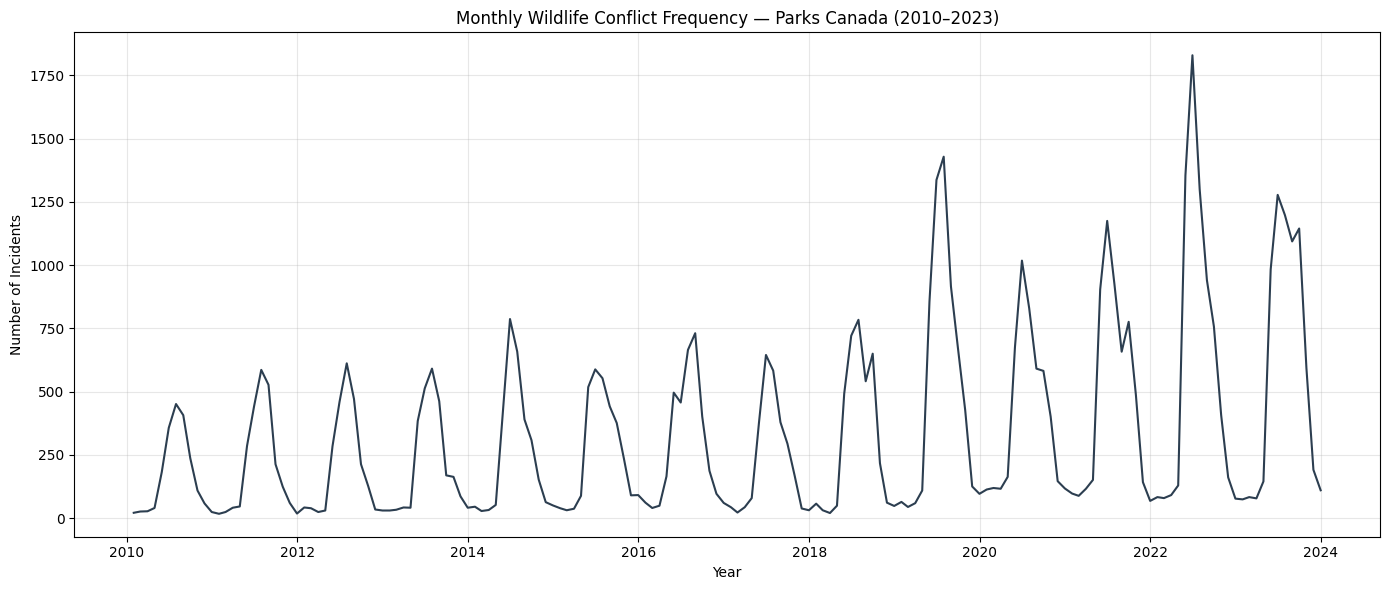

In [ ]:
# 1. Monthly incident frequency over the full 2010-2023 period
plt.figure(figsize=(14, 6))
plt.plot(monthly_df.index, monthly_df['incident_count'],
         color='#2c3e50', linewidth=1.5)
plt.title('Monthly Wildlife Conflict Frequency — Parks Canada (2010–2023)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

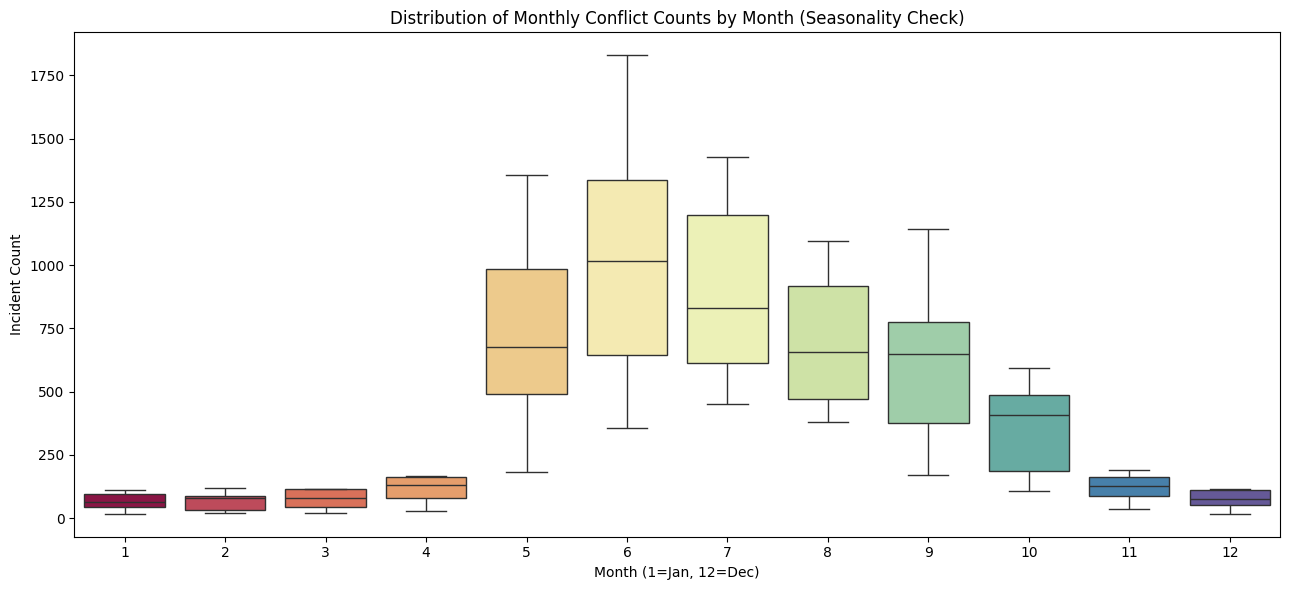

In [ ]:
# 2. Seasonal boxplot — distribution of monthly counts by month across all years
df_ts['Monthly_Count'] = df_ts.groupby(
    [df_ts['Date'].dt.year, df_ts['Date'].dt.month]
)['RISK_LEVEL'].transform('count')

plt.figure(figsize=(13, 6))
sns.boxplot(data=df_ts, x='Month', y='Monthly_Count', hue='Month',
            palette='Spectral', legend=False)
plt.title('Distribution of Monthly Conflict Counts by Month (Seasonality Check)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Incident Count')
plt.tight_layout()
plt.show()

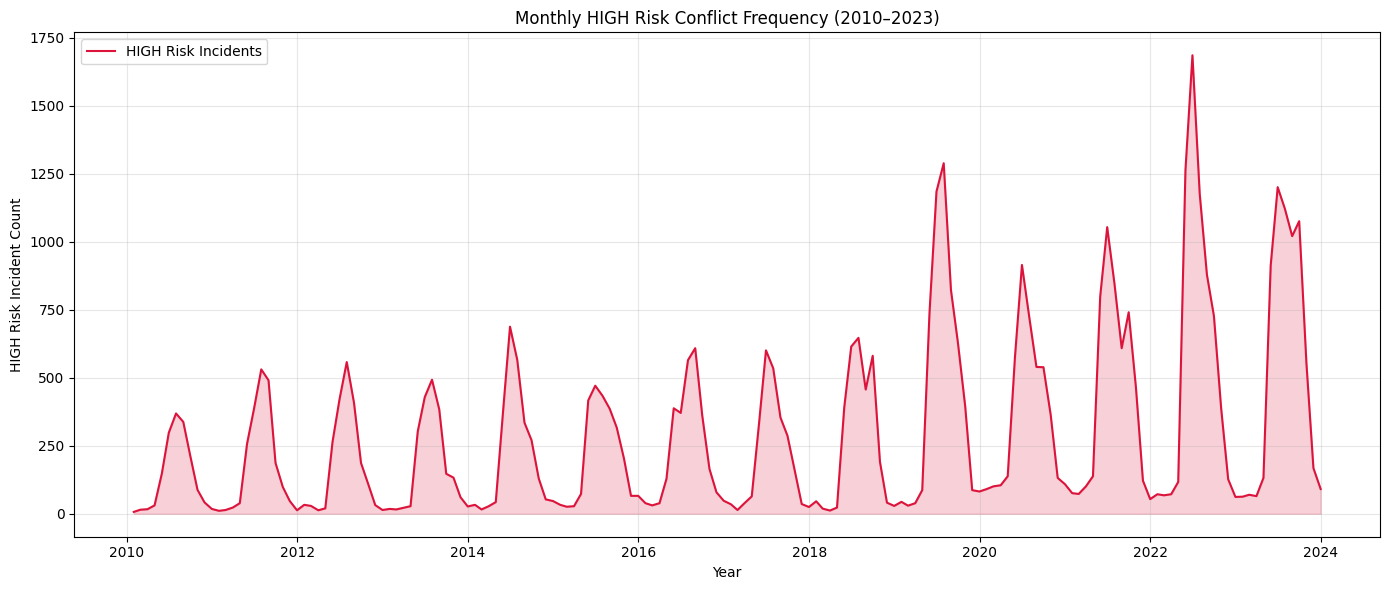

In [ ]:
# 3. HIGH risk incidents over time — the most important trend for forecasting
plt.figure(figsize=(14, 6))
plt.plot(monthly_df.index, monthly_df['high_count'],
         color='crimson', linewidth=1.5, label='HIGH Risk Incidents')
plt.fill_between(monthly_df.index, monthly_df['high_count'],
                 alpha=0.2, color='crimson')
plt.title('Monthly HIGH Risk Conflict Frequency (2010–2023)')
plt.xlabel('Year')
plt.ylabel('HIGH Risk Incident Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

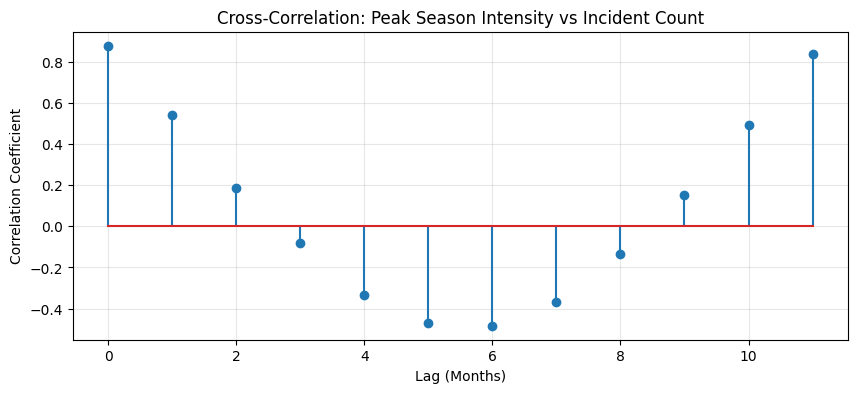

Positive correlation at lag 0 confirms peak season drives incident frequency.


In [ ]:
# 4. Cross-correlation: does peak season intensity lead incident counts?
# (Same concept as Chitwan's lunar cross-correlation)
lags = 12
corr = [
    monthly_df['incident_count'].corr(monthly_df['peak_intensity'].shift(i))
    for i in range(lags)
]
plt.figure(figsize=(10, 4))
plt.stem(range(lags), corr)
plt.title('Cross-Correlation: Peak Season Intensity vs Incident Count')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.show()
print("Positive correlation at lag 0 confirms peak season drives incident frequency.")

## Step 4 — ADF Stationarity Test

In [ ]:
monthly_series = monthly_df['incident_count'].astype(float)

result = adfuller(monthly_series)
print('--- ADF Test Results ---')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.6f}')

if result[1] < 0.05:
    print("Result: Data is stationary. Proceed to ACF/PACF.")
else:
    print("Result: Data is non-stationary. Will need d=1 in ARIMA.")

--- ADF Test Results ---
ADF Statistic : -0.5022
p-value       : 0.891582
Result: Data is non-stationary. Will need d=1 in ARIMA.


## Step 5 — ACF and PACF Plots
ACF tells us the MA term `q`. PACF tells us the AR term `p`.

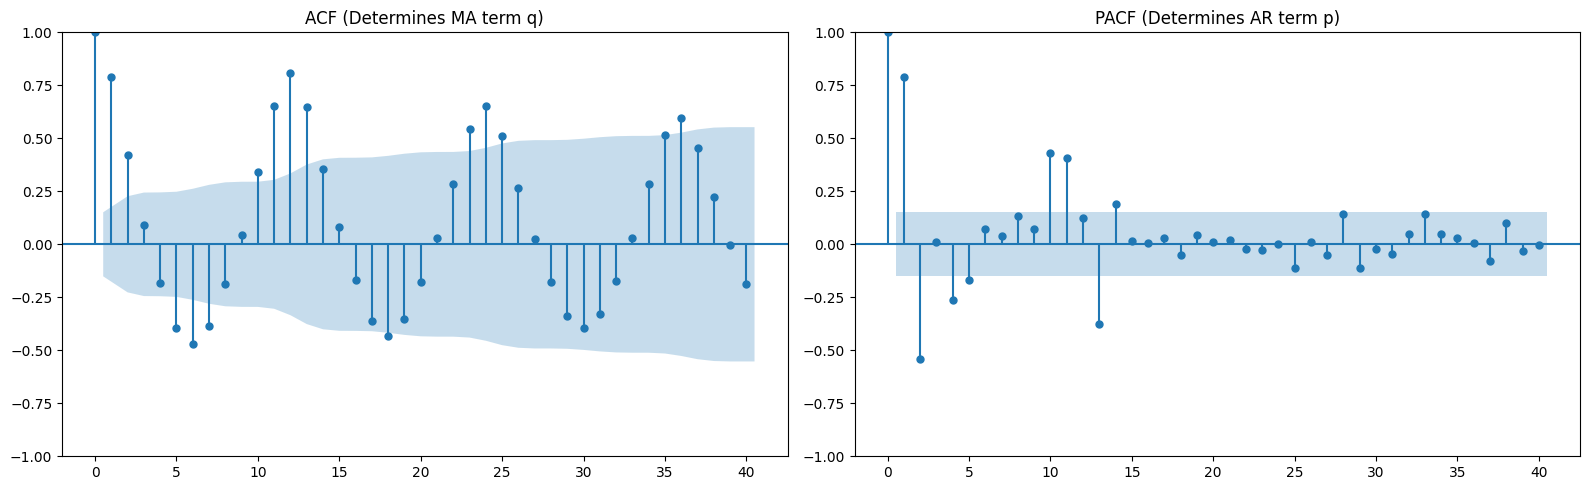

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(monthly_series, lags=40, ax=ax1)
ax1.set_title('ACF (Determines MA term q)')

plot_pacf(monthly_series, lags=40, ax=ax2)
ax2.set_title('PACF (Determines AR term p)')

plt.tight_layout()
plt.show()

## Step 6 — ARIMA Model
Baseline model — no seasonal component, no exogenous variable.
Forecasts the next 12 months of total incident counts.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


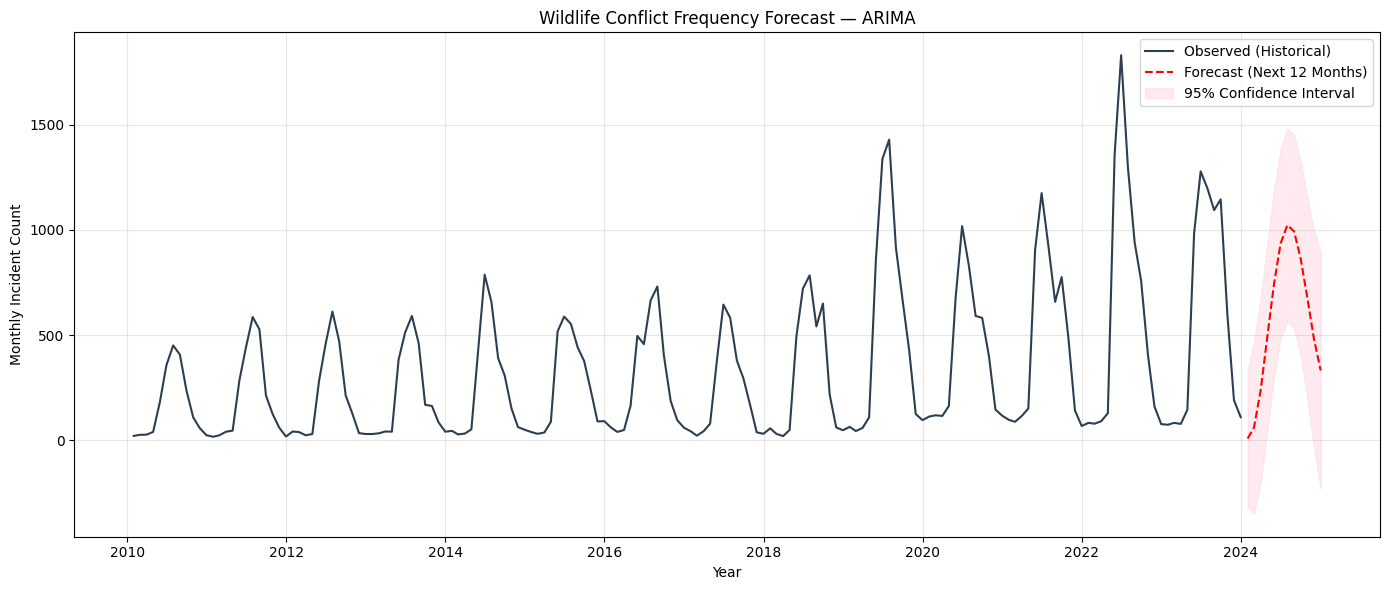

                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                  168
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1092.773
Date:                Sat, 23 May 2026   AIC                           2195.546
Time:                        05:33:42   BIC                           2211.136
Sample:                    01-31-2010   HQIC                          2201.874
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6624      0.023     70.845      0.000       1.616       1.708
ar.L2         -0.9131      0.027    -33.236      0.000      -0.967      -0.859
ma.L1         -1.8744      0.025    -73.575      0.0

In [ ]:
# order=(p, d, q) — adjust p and q based on ACF/PACF plots above
# d=1 if ADF test showed non-stationary, d=0 if stationary
arima_model = ARIMA(monthly_series, order=(2, 1, 2))
arima_fit   = arima_model.fit()

forecast_steps = 12
forecast     = arima_fit.get_forecast(steps=forecast_steps)
forecast_idx = pd.date_range(
    start=monthly_series.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps, freq='MS'
)
forecast_values = forecast.predicted_mean
conf_int        = forecast.conf_int()

plt.figure(figsize=(14, 6))
plt.plot(monthly_series, label='Observed (Historical)', color='#2c3e50')
plt.plot(forecast_idx, forecast_values,
         label='Forecast (Next 12 Months)', color='red', linestyle='--')
plt.fill_between(forecast_idx,
                 conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Wildlife Conflict Frequency Forecast — ARIMA')
plt.xlabel('Year')
plt.ylabel('Monthly Incident Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(arima_fit.summary())

## Step 7 — Train / Test Split for Validation
Train on 2010–2021, test on 2022–2023.
This lets us compare forecast vs reality on data the model never saw.

In [ ]:
# Use data up to end of 2021 for training
train_data = monthly_df[monthly_df.index.year <= 2021].copy()
test_data  = monthly_df[monthly_df.index.year >= 2022].copy()

print(f"Training: {train_data.shape[0]} months ({train_data.index[0].year}–{train_data.index[-1].year})")
print(f"Test:     {test_data.shape[0]} months ({test_data.index[0].year}–{test_data.index[-1].year})")

Training: 144 months (2010–2021)
Test:     24 months (2022–2023)


## Step 8 — SARIMA Baseline (No Exogenous Variable)
Adds seasonal component (1,1,1,12) to capture the annual 12-month cycle
of Canadian wildlife activity — same seasonal order as Chitwan.

In [ ]:
sarima_base = SARIMAX(
    train_data['incident_count'],
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

base_forecast = sarima_base.get_forecast(steps=len(test_data))
base_means    = base_forecast.predicted_mean
base_conf     = base_forecast.conf_int()

rmse_base = np.sqrt(mean_squared_error(
    test_data['incident_count'], base_means
))
print(f"Baseline SARIMA RMSE: {rmse_base:.2f}")

Baseline SARIMA RMSE: 235.19


## Step 9 — SARIMAX with Peak Season as Exogenous Variable
Same concept as Chitwan's lunar-aware model — we give the model an external
variable it can use to anticipate spikes before they happen.

In [ ]:
sarimax_peak = SARIMAX(
    train_data['incident_count'],
    exog=train_data['peak_intensity'],
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

# For forecasting we need future exog values — peak season is known in advance
# since it's calendar-based (summer/fall months are always the same)
peak_forecast = sarimax_peak.get_forecast(
    steps=len(test_data),
    exog=test_data['peak_intensity']
)
peak_means = peak_forecast.predicted_mean
peak_conf  = peak_forecast.conf_int()

rmse_peak = np.sqrt(mean_squared_error(
    test_data['incident_count'], peak_means
))
print(f"SARIMAX (Peak Season) RMSE: {rmse_peak:.2f}")

SARIMAX (Peak Season) RMSE: 107.48


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Step 10 — Comparison Plot: Baseline vs Peak-Aware Model

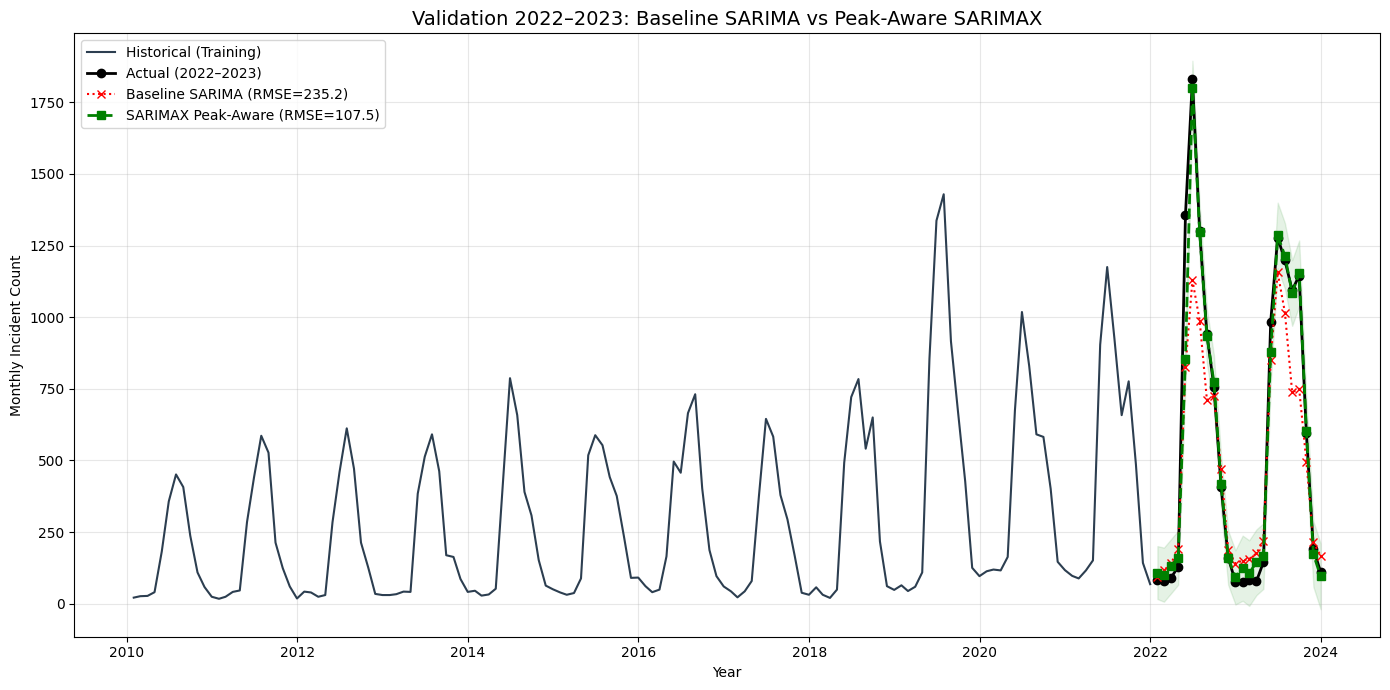


Baseline SARIMA RMSE  : 235.19
Peak-Aware SARIMAX RMSE: 107.48
RMSE Improvement       : 54.3%


In [ ]:
plt.figure(figsize=(14, 7))

# Historical data
plt.plot(train_data.index, train_data['incident_count'],
         color='#2c3e50', linewidth=1.5, label='Historical (Training)')

# Actual test period
plt.plot(test_data.index, test_data['incident_count'],
         color='black', linewidth=2, marker='o',
         label='Actual (2022–2023)')

# Baseline SARIMA forecast
plt.plot(base_means.index, base_means,
         color='red', linestyle=':', marker='x',
         label=f'Baseline SARIMA (RMSE={rmse_base:.1f})')

# Peak-aware SARIMAX forecast
plt.plot(peak_means.index, peak_means,
         color='green', linestyle='--', marker='s', linewidth=2,
         label=f'SARIMAX Peak-Aware (RMSE={rmse_peak:.1f})')

# Confidence intervals
plt.fill_between(peak_means.index,
                 peak_conf.iloc[:, 0], peak_conf.iloc[:, 1],
                 color='green', alpha=0.1)

plt.title('Validation 2022–2023: Baseline SARIMA vs Peak-Aware SARIMAX', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Monthly Incident Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

improvement = ((rmse_base - rmse_peak) / rmse_base) * 100
print(f"\nBaseline SARIMA RMSE  : {rmse_base:.2f}")
print(f"Peak-Aware SARIMAX RMSE: {rmse_peak:.2f}")
print(f"RMSE Improvement       : {improvement:.1f}%")

## Step 11 — Future Forecast: Next 12 Months
Refit the best model on the full dataset and forecast ahead.

Future peak intensity values (historically-calibrated):
  Month  Peak_Intensity  Is_Peak
2024-01             0.0        0
2024-02             0.0        0
2024-03             0.0        0
2024-04             0.0        0
2024-05             0.0        0
2024-06           829.0        1
2024-07           797.5        1
2024-08           610.7        1
2024-09           485.3        1
2024-10           271.0        1
2024-11             0.0        0
2024-12             0.0        0


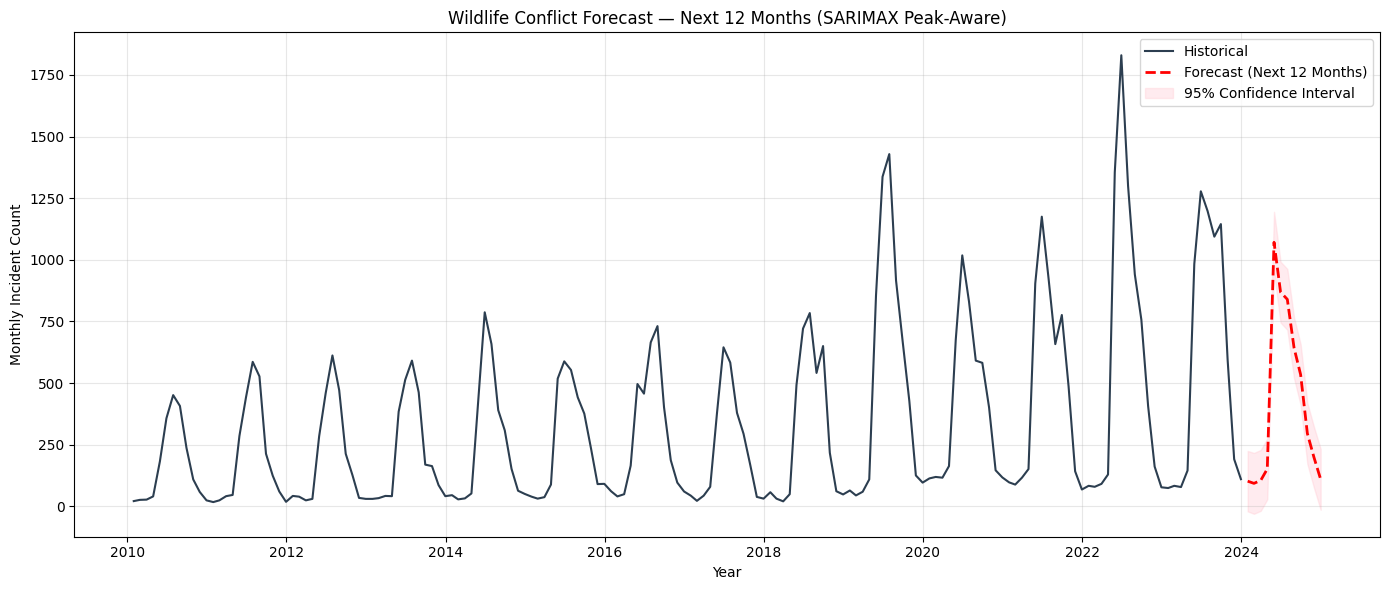


--- Forecasted Monthly Counts ---
  Month  Predicted  Lower_95  Upper_95  Is_Peak_Season
2024-01      101.8       0.0     224.4               0
2024-02       92.9       0.0     216.4               0
2024-03      105.0       0.0     228.5               0
2024-04      151.5      28.0     275.0               0
2024-05     1071.2     947.7    1194.7               0
2024-06      868.9     745.4     992.4               1
2024-07      839.5     716.0     963.0               1
2024-08      642.3     518.8     765.8               1
2024-09      534.4     410.9     657.9               1
2024-10      295.2     171.7     418.8               1
2024-11      199.4      75.9     322.9               0
2024-12      109.3       0.0     232.8               0


In [ ]:
# Refit on full data
final_model = SARIMAX(
    monthly_df['incident_count'],
    exog=monthly_df['peak_intensity'],
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

# Build future dates
future_dates  = pd.date_range(
    start=monthly_df.index[-1] + pd.DateOffset(months=1),
    periods=12, freq='ME'
)
future_months = future_dates.month

# Future exog must match the same scale as training data
# In training, peak_intensity = count of peak-season incidents per month
# So we use the historical average peak_intensity per calendar month
# instead of a binary 0/1 — this keeps the scale consistent
monthly_avg_peak = monthly_df.groupby(monthly_df.index.month)['peak_intensity'].mean()
future_peak = pd.Series(
    [monthly_avg_peak[m] for m in future_months],
    index=future_dates
)

print("Future peak intensity values (historically-calibrated):")
print(pd.DataFrame({
    'Month':          future_dates.strftime('%Y-%m'),
    'Peak_Intensity': future_peak.round(1).values,
    'Is_Peak':        future_months.isin([6,7,8,9,10]).astype(int)
}).to_string(index=False))

# Generate forecast
future_forecast = final_model.get_forecast(steps=12, exog=future_peak)
future_means    = future_forecast.predicted_mean
future_conf     = future_forecast.conf_int()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_df.index, monthly_df['incident_count'],
         color='#2c3e50', linewidth=1.5, label='Historical')
plt.plot(future_dates, future_means,
         color='red', linestyle='--', linewidth=2, label='Forecast (Next 12 Months)')
plt.fill_between(future_dates,
                 future_conf.iloc[:, 0], future_conf.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Wildlife Conflict Forecast — Next 12 Months (SARIMAX Peak-Aware)')
plt.xlabel('Year')
plt.ylabel('Monthly Incident Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Forecast table
print("\n--- Forecasted Monthly Counts ---")
forecast_df = pd.DataFrame({
    'Month':          future_dates.strftime('%Y-%m'),
    'Predicted':      future_means.round(1).values,
    'Lower_95':       future_conf.iloc[:, 0].round(1).values,
    'Upper_95':       future_conf.iloc[:, 1].round(1).values,
    'Is_Peak_Season': future_months.isin([6,7,8,9,10]).astype(int)
})

# Incident counts cannot be negative — clip lower bound to 0
forecast_df['Lower_95'] = forecast_df['Lower_95'].clip(lower=0)

print(forecast_df.to_string(index=False))

## Step 12 — Model Summary and Export

In [ ]:
print(final_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                       incident_count   No. Observations:                  168
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -864.280
Date:                              Sat, 23 May 2026   AIC                           1744.560
Time:                                      05:38:58   BIC                           1768.907
Sample:                                  01-31-2010   HQIC                          1754.449
                                       - 12-31-2023                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
peak_intensity     0.9461      0.139      6.796      0.000       0.673       1.219
ar.L1  

In [ ]:
import joblib

# Save the fitted model for backend use
joblib.dump(final_model, '/content/drive/MyDrive/parks_canada_sarimax_model.joblib')

# Save the forecast table for frontend use
forecast_df.to_csv(
    '/content/drive/MyDrive/parks_canada_conflict_forecast.csv',
    index=False
)

# Save the full monthly series for frontend trend charts
monthly_df.to_csv(
    '/content/drive/MyDrive/parks_canada_monthly_series.csv'
)

print("Exported:")
print("  parks_canada_sarimax_model.joblib       — fitted model for backend")
print("  parks_canada_conflict_forecast.csv      — 12-month forecast for frontend")
print("  parks_canada_monthly_series.csv         — historical monthly counts for charts")

Exported:
  parks_canada_sarimax_model.joblib       — fitted model for backend
  parks_canada_conflict_forecast.csv      — 12-month forecast for frontend
  parks_canada_monthly_series.csv         — historical monthly counts for charts
